In [1]:
from functools import partial

import matplotlib.pyplot as plt

from superfv import HydroSolver, TimeIntegrator
import superfv.initial_conditions as superic
from spd.spectral_difference.sd_simulator import SD_Simulator
from spd.sdfb_simulator import SDFB_Simulator
import spd.initial_conditions as spdic

In [2]:
NDOF = 128
p = 7
T = 1.0

In [3]:
super_sim = HydroSolver(
    ic=partial(superic.square, vx=1.0),
    nx=NDOF,
    p=p,
    gamma=1.4,
    use_MOOD=True,
    rtol=1e-5,
    use_SED=True,
)
super_sim.run(T, time_integrator=TimeIntegrator.SSPRK3)

SuperFV: 350 steps | t=1.00e+00/1.00e+00, dt=9.03e-04 | rho_min=1.00e+00 | E_cons=1.14e-13 | wall=4.49e-01s (done)


In [4]:
N = NDOF // (p + 1)

spd_sim = SDFB_Simulator(
    p=p,
    N=(N,),
    init_fct=spdic.step_function(),
    cfl_coeff=0.4,
    use_cupy=False,
    time_integrator="rk3",
    gamma=1.4,
    scheme="SDFB",
    riemann_solver_sd="hllc",  # SD high-order flux
    riemann_solver_fv="hllc",  # MUSCL fallback flux
    fallback="MUSCL",          # plain MUSCL fallback, not MUSCL-Hancock
    FB=True,
    tolerance=1e-5, 
    NAD="", 
    PAD=True,
    SED=True,
)
spd_sim.perform_time_evolution(T)

/Users/jonathan/Desktop/spd/spd/trouble_detection.py:173: RuntimeWarning: invalid value encountered in divide
  -np.where(dv < 0, np.where(vL > 0, vL, 0), np.where(vL < 0, vL, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:180: RuntimeWarning: invalid value encountered in divide
  alphaR = np.where(dv > 0, np.where(vR > 0, vR, 0), np.where(vR < 0, vR, 0)) / dv
/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: divide by zero encountered in divide
  ratio = SlopeR/SlopeL
/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = SlopeR/SlopeL
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:173: RuntimeWarning: divide by zero encountered in divide
  -np.where(dv < 0, np.where(vL > 0, vL, 0), np.where(vL < 0, vL, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:180: RuntimeWarning: divide by zero encountered in divide
  alphaR = np.where(dv > 0, np.where(vR > 0, vR, 0), n

t=1.0, steps taken 699, time taken 0.653, bzcps = 0.0


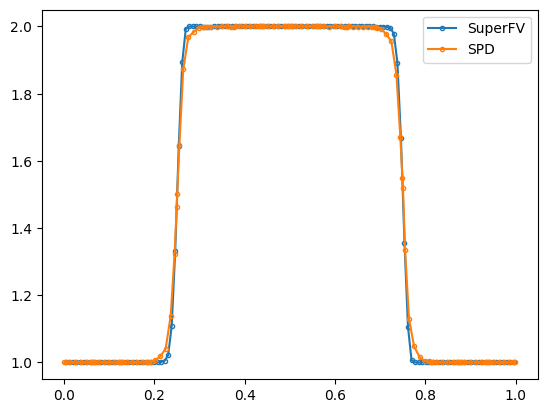

In [5]:
plt.plot(
    super_sim.mesh.x_centers,
    super_sim.snapshot_history[-1].u[super_sim.idx("rho"), :, 0, 0],
    label="SuperFV",
    linestyle="-",
    marker=".",
    mfc="none",
)
plt.plot(
    spd_sim.dm.X_sp.flatten(),
    spd_sim.dm.U_sp[0].flatten(),
    label="SPD",
    linestyle="-",
    marker=".",
    mfc="none",
)
plt.legend()